# Análisis Estadístico de Tiempos de Entrega
**Proyecto:** Optimización Logística E-Commerce México
**Responsable:** Persona 3 (Analista de Datos Senior)

## Objetivo del Análisis
Identificar los factores críticos que impactan los tiempos de entrega (SLA) para optimizar la operación.
Este reporte examina 4 dimensiones clave:
1. **Logística:** Rendimiento de transportistas y tipos de servicio.
2. **Geografía:** Brechas de infraestructura por región.
3. **Temporalidad:** Impacto de la saturación en temporada alta.
4. **Negocio:** Eficiencia por canal de venta y tipo de producto.

### 1. Configuración del Entorno y Carga de Datos
En esta sección importamos nuestra librería personalizada de análisis (`analysis_statistics`) que contiene las funciones estadísticas y de visualización.
Cargamos el dataset limpio (`dataset_clean.csv`) y verificamos que las fechas y variables calculadas estén listas.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
import analysis_statistics as au

plt.style.use('ggplot')

# Carga
file_path = '../data/processed/dataset_clean.csv'
df = au.cargar_y_preparar_datos(file_path)
print(f"Datos listos: {df.shape}")

Datos listos: (9515, 41)


### 2. Auditoría Visual de Datos (Top 50)
A continuación, presentamos una muestra de los registros más relevantes para inspección visual.
**Código de colores:**
* 🟢 **Verde:** Entregas rápidas y eficientes.
* 🔴 **Rojo:** Entregas con retrasos significativos (Outliers).
Esta vista permite detectar patrones puntuales que los promedios podrían ocultar.

In [7]:
# VISTA DE DATOS CLAVE (Top 50)

# 1. Configuración para asegurar que Jupyter muestre las 50 filas sin ocultarlas
pd.set_option('display.max_rows', 50)

# 2. Seleccionamos solo las columnas "Protagonistas" de tu análisis
columnas_vip = [
    'order_id',             # Identificador
    'shipping_carrier',     # Dimensión Logística
    'shipping_tier',        # Nivel de servicio
    'customer_region',      # Dimensión Geográfica
    'is_peak_season',       # Dimensión Temporal
    'shipped_date',         # Para referencia
    'delivered_date',       # Para referencia
    'dias_reales',          # VARIABLE OBJETIVO (Calculada)
    'delivery_met_promise'  # Resultado (¿Cumplió?)
]

# 3. Mostrar el DataFrame filtrado (Primeros 50 registros)
print(f"--- VISTA PREVIA: Top 50 Registros Clave para el Análisis ---")

# Verificamos que las columnas existan antes de imprimir para evitar errores
cols_existentes = [c for c in columnas_vip if c in df.columns]

# Usamos .style.background_gradient para resaltar visualmente los tiempos de entrega
# (Verde = Rápido, Rojo = Lento)
display(
    df[cols_existentes].head(50)
    .style.background_gradient(subset=['dias_reales'], cmap='RdYlGn_r')
    .format({'dias_reales': '{:.0f} días'})
)

--- VISTA PREVIA: Top 50 Registros Clave para el Análisis ---


,order_id,shipping_carrier,shipping_tier,customer_region,is_peak_season,shipped_date,delivered_date,dias_reales,delivery_met_promise
0,ECOMMX-2024-00000,Estafeta,Estándar,Norte,0,2025-03-23 14:47:03,2025-03-28 14:47:03,5 días,1
1,ECOMMX-2024-00001,Estafeta,Estándar,Centro,1,2025-12-23 02:25:19,2025-12-25 02:25:19,2 días,1
2,ECOMMX-2024-00002,FedEx,Estándar,Occidente,0,2025-09-08 03:26:12,2025-09-10 03:26:12,2 días,1
3,ECOMMX-2024-00003,Estafeta,Estándar,Norte,0,2025-08-08 12:45:58,2025-08-15 12:45:58,7 días,0
4,ECOMMX-2024-00004,DHL,Estándar,Centro,0,2025-10-17 15:55:51,2025-10-20 15:55:51,3 días,0
5,ECOMMX-2024-00005,FedEx,Express,Centro,0,2025-02-04 08:50:34,2025-02-07 08:50:34,3 días,0
6,ECOMMX-2024-00006,Paquetexpress,Estándar,Norte,0,2025-05-01 05:43:22,2025-05-08 05:43:22,7 días,1
7,ECOMMX-2024-00007,FedEx,Estándar,Occidente,0,2025-02-18 20:29:21,2025-02-23 20:29:21,5 días,0
8,ECOMMX-2024-00008,FedEx,Estándar,Occidente,1,2025-11-29 14:26:39,2025-12-07 14:26:39,8 días,0
9,ECOMMX-2024-00009,DHL,Estándar,Occidente,0,2025-10-12 07:05:21,2025-10-13 07:05:21,1 días,1


### 3. Dimensión Logística: ¿Quién entrega mejor?
El factor más directo en la experiencia del cliente es el proveedor logístico.
En este bloque analizamos:
* **Transportistas:** Comparamos la velocidad promedio y la consistencia (varianza) de cada carrier (DHL, Estafeta, etc.).
* **Nivel de Servicio:** Validamos si pagar por envío "Express" realmente reduce los días de espera.
* **Tipo de Ruta:** Medimos el impacto de la distancia operativa (Local vs. Nacional).


>>> ANÁLISIS DE: SHIPPING_CARRIER <<<
¿Diferencia significativa (p<0.05)? SI (p-value=0.0000)


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_categoria, y='dias_reales', order=orden, palette='viridis')


,Promedio,Mediana,Desv_Std,Total_Envios
shipping_carrier,,,,
DHL,3.052260,3.0,1.366651,2124
UPS,3.902023,4.0,1.765273,939
FedEx,4.250859,4.0,1.587220,1746
Estafeta,6.170101,6.0,2.249502,2669
Redpack,7.194323,7.0,2.335955,458
Paquetexpress,7.994681,8.0,2.578184,188
Correos de México,12.371675,12.0,3.871204,1391


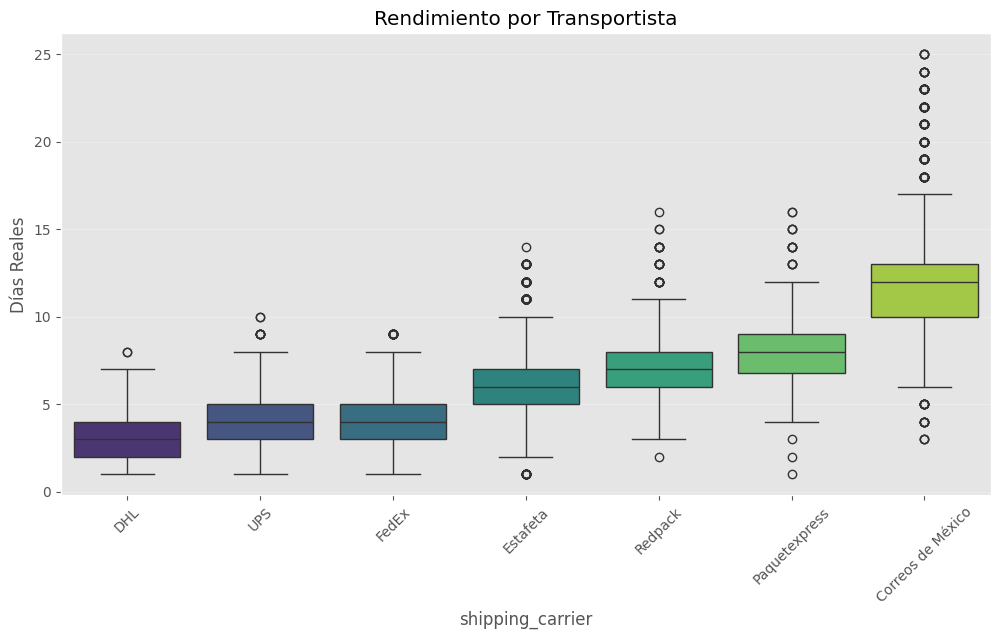


>>> ANÁLISIS DE: SHIPPING_TIER <<<
¿Diferencia significativa (p<0.05)? NO (p-value=0.0845)


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_categoria, y='dias_reales', order=orden, palette='viridis')


,Promedio,Mediana,Desv_Std,Total_Envios
shipping_tier,,,,
Estándar,5.862188,5.0,3.732870,8098
Express,6.049400,5.0,3.964046,1417


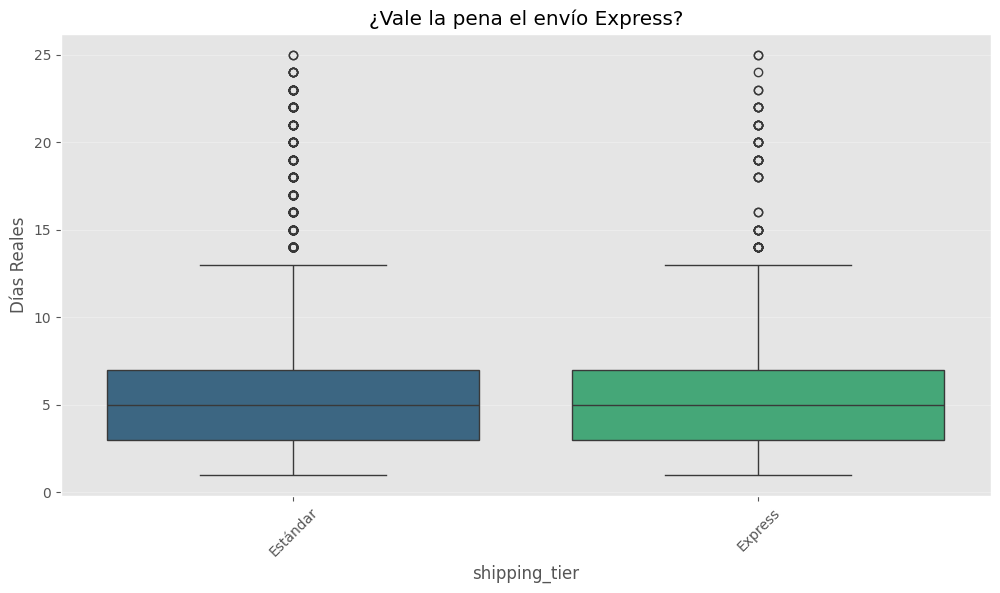


>>> ANÁLISIS DE: SHIPPING_TYPE <<<
¿Diferencia significativa (p<0.05)? SI (p-value=0.0000)


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_categoria, y='dias_reales', order=orden, palette='viridis')


,Promedio,Mediana,Desv_Std,Total_Envios
shipping_type,,,,
local,2.491103,2.0,1.789082,281
regional,4.385353,4.0,2.761017,2608
nacional,6.626471,6.0,3.916188,6626


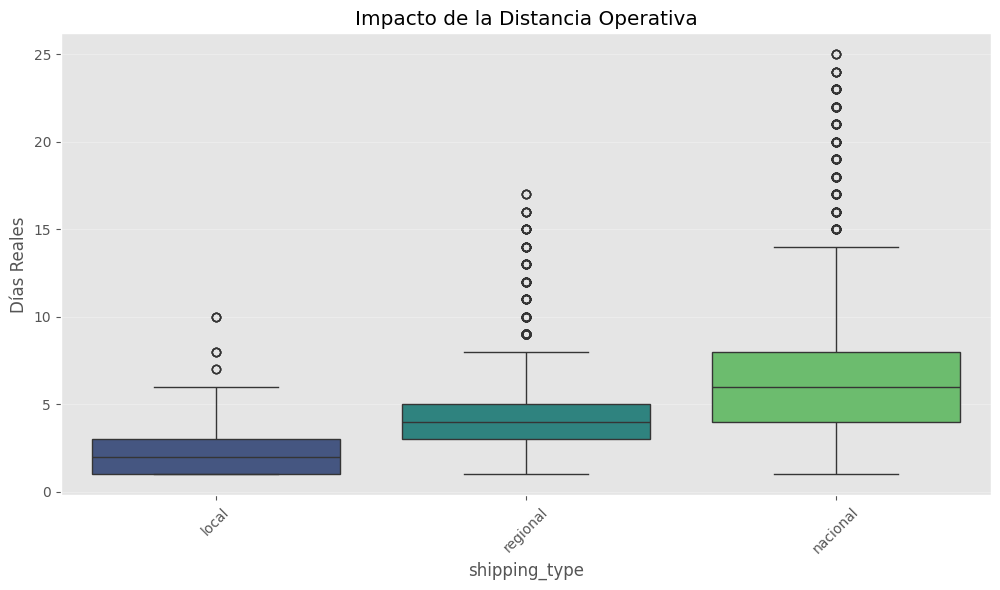

In [2]:
# 1.1 Análisis por Transportista (Quién es el más rápido/lento)
tabla_carrier, graf_carrier = au.analizar_impacto_categoria(
    df, 'shipping_carrier', 'Rendimiento por Transportista'
)
display(tabla_carrier)
plt.show()

# 1.2 Análisis por Nivel de Servicio (Express vs Estándar)
tabla_tier, graf_tier = au.analizar_impacto_categoria(
    df, 'shipping_tier', '¿Vale la pena el envío Express?'
)
display(tabla_tier)
plt.show()

# 1.3 Tipo de Ruta (Local vs Nacional)
tabla_ruta, graf_ruta = au.analizar_impacto_categoria(
    df, 'shipping_type', 'Impacto de la Distancia Operativa'
)
display(tabla_ruta)
plt.show()

### 4. Dimensión Geográfica: Infraestructura y Cobertura
México presenta retos orográficos complejos. Analizamos si existe una "brecha logística" basada en la ubicación del cliente.
* **Regiones:** Identificamos zonas con rezago sistemático (ej. Sur vs. Norte).
* **Urbanidad:** Contrastamos la eficiencia en grandes ciudades (Urbano) contra zonas de difícil acceso (Rural).


>>> ANÁLISIS DE: CUSTOMER_REGION <<<
¿Diferencia significativa (p<0.05)? SI (p-value=0.0000)


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_categoria, y='dias_reales', order=orden, palette='viridis')


,Promedio,Mediana,Desv_Std,Total_Envios
customer_region,,,,
Centro,4.201108,4.0,2.739887,2889
Occidente,6.573730,5.0,3.953619,2048
Sur,6.610747,6.0,3.883110,1526
Norte,6.650742,6.0,3.899908,2156
Península,6.715402,6.0,3.929892,896


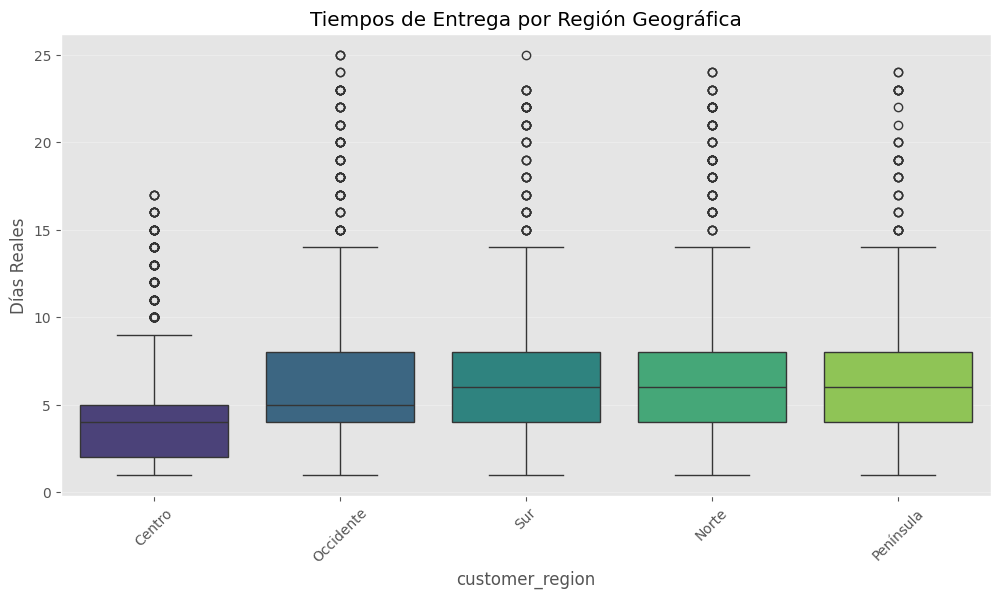

c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_categoria, y='dias_reales', order=orden, palette='viridis')


Interpretación: Observa si el 'Sur' o zonas alejadas tienen promedios más altos.

>>> ANÁLISIS DE: IS_URBAN <<<
¿Diferencia significativa (p<0.05)? NO (p-value=0.4248)


,Promedio,Mediana,Desv_Std,Total_Envios
is_urban,,,,
0,5.836947,5.0,3.649841,2398
1,5.907967,5.0,3.807826,7117


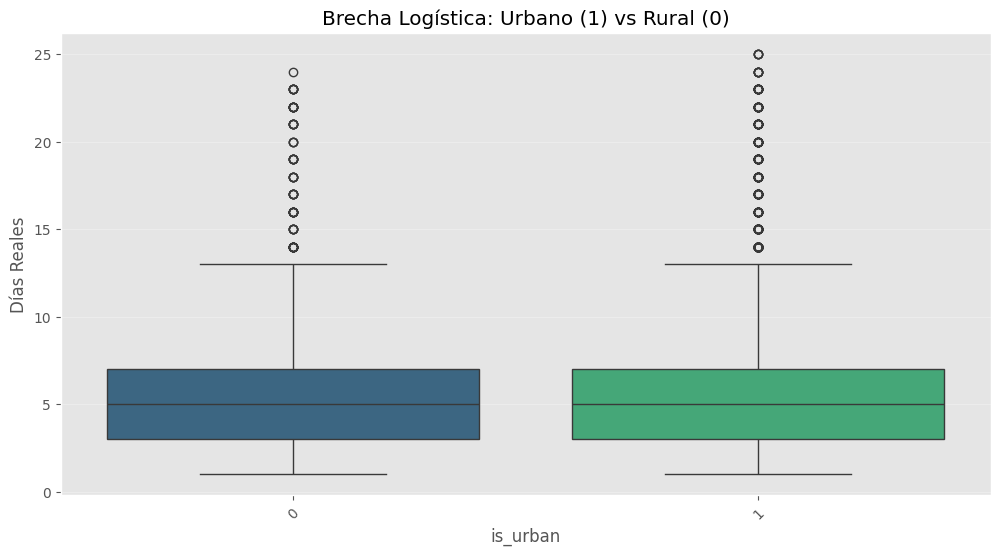

In [3]:
# 2.1 Regiones de México
tabla_region, graf_region = au.analizar_impacto_categoria(
    df, 'customer_region', 'Tiempos de Entrega por Región Geográfica'
)
display(tabla_region)
plt.show()

print("Interpretación: Observa si el 'Sur' o zonas alejadas tienen promedios más altos.")

# 2.2 Urbano vs Rural (Brecha de infraestructura)
tabla_urbano, graf_urbano = au.analizar_impacto_categoria(
    df, 'is_urban', 'Brecha Logística: Urbano (1) vs Rural (0)'
)
display(tabla_urbano)
plt.show()

### 5. Dimensión Temporal: El "Estrés" del Sistema
Los sistemas logísticos suelen colapsar bajo presión.
Analizamos el impacto de la variable `is_peak_season` (Temporada Alta: Hot Sale, Navidad) para cuantificar cuántos días adicionales de retraso genera la saturación de la red.
> **Nota:** Se aplica una prueba estadística para confirmar si la degradación del servicio es significativa.


>>> ANÁLISIS DE: IS_PEAK_SEASON <<<
¿Diferencia significativa (p<0.05)? SI (p-value=0.0000)


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_categoria, y='dias_reales', order=orden, palette='viridis')


,Promedio,Mediana,Desv_Std,Total_Envios
is_peak_season,,,,
0,5.139994,4.0,3.029988,7036
1,8.018959,7.0,4.725649,2479


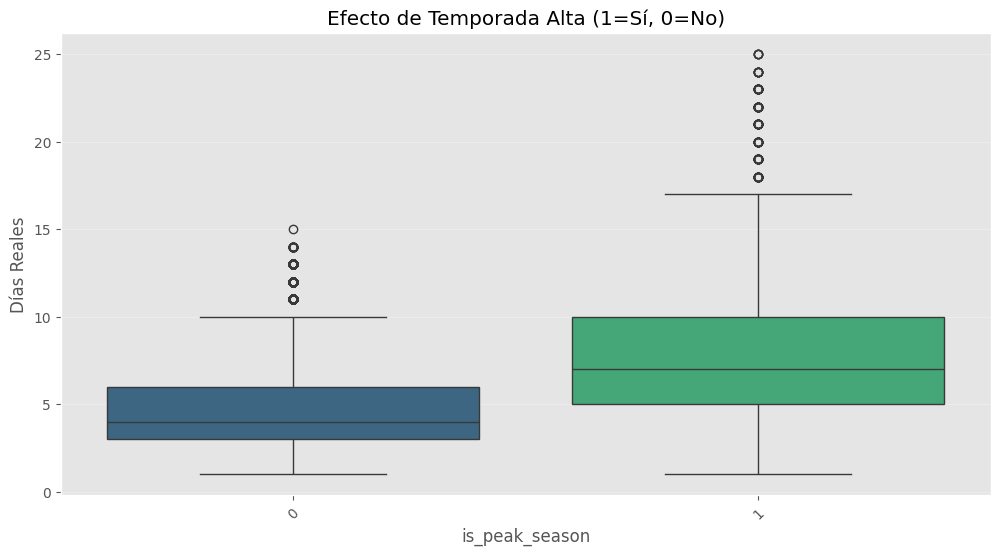

Nota: Si el p-value es < 0.05, el colapso logístico en temporada alta es estadísticamente real.


In [4]:
# 3.1 Temporada Alta (Hot Sale/Navidad)
tabla_season, graf_season = au.analizar_impacto_categoria(
    df, 'is_peak_season', 'Efecto de Temporada Alta (1=Sí, 0=No)'
)
display(tabla_season)
plt.show()

print("Nota: Si el p-value es < 0.05, el colapso logístico en temporada alta es estadísticamente real.")

### 6. Dimensión de Negocio: Canales y Productos
No todos los pedidos nacen igual.
* **Plataforma:** ¿Los pedidos de Marketplaces (Amazon/Mercado Libre) se procesan más rápido que los de nuestro sitio web propio?
* **Categoría:** ¿El tamaño o tipo de producto (ej. Muebles vs. Celulares) afecta la velocidad de despacho?


>>> ANÁLISIS DE: PLATFORM_NAME <<<
¿Diferencia significativa (p<0.05)? SI (p-value=0.0194)


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_categoria, y='dias_reales', order=orden, palette='viridis')


,Promedio,Mediana,Desv_Std,Total_Envios
platform_name,,,,
Walmart,5.632893,5.0,3.421864,681
Sitio Web Propio,5.692472,5.0,3.653025,1408
Liverpool,5.780412,5.0,3.768347,970
Amazon México,5.888561,5.0,3.752509,2369
Mercado Libre,6.017712,5.0,3.887222,3331
Coppel,6.072751,5.0,3.776364,756


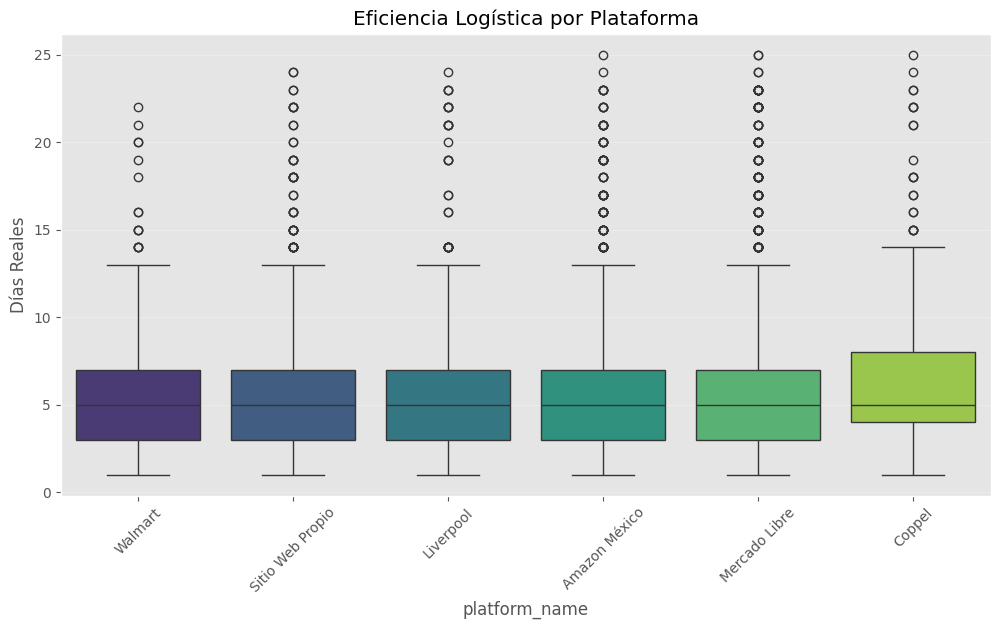


>>> ANÁLISIS DE: PRODUCT_CATEGORY <<<
¿Diferencia significativa (p<0.05)? NO (p-value=0.2847)


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_categoria, y='dias_reales', order=orden, palette='viridis')


,Promedio,Mediana,Desv_Std,Total_Envios
product_category,,,,
Salud y Belleza,5.792567,5.0,3.590912,1157
Libros y Educación,5.829299,5.0,3.753761,785
Hogar y Jardín,5.849217,5.0,3.725051,1532
Electrónicos,5.851292,5.0,3.738243,2051
Juguetes y Bebés,5.857143,5.0,3.908649,595
Moda y Accesorios,5.909200,5.0,3.806882,2500
Deportes,6.196648,5.0,3.939899,895


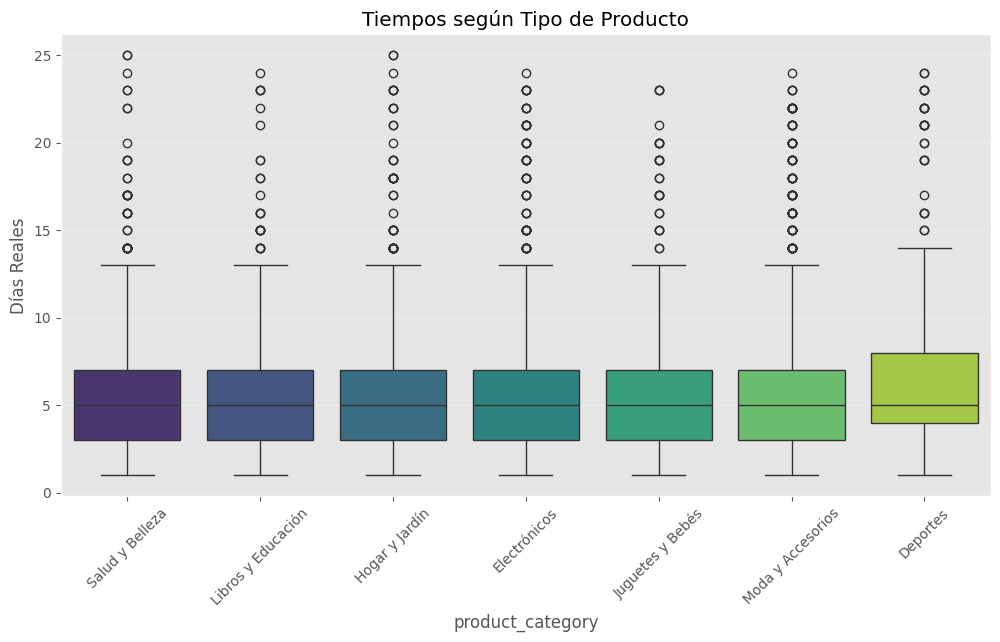

In [5]:
# 4.1 Canal de Venta (Marketplace vs Directo)
tabla_plat, graf_plat = au.analizar_impacto_categoria(
    df, 'platform_name', 'Eficiencia Logística por Plataforma'
)
display(tabla_plat)
plt.show()

# 4.2 Categoría de Producto (Volumetría)
tabla_cat, graf_cat = au.analizar_impacto_categoria(
    df, 'product_category', 'Tiempos según Tipo de Producto'
)
display(tabla_cat)
plt.show()

### 7. Mapa de Correlaciones (Factores de Influencia)
Utilizamos un Mapa de Calor para visualizar qué variables están matemáticas conectadas.
* **Rojo/Positivo:** Factores que AUMENTAN el tiempo (ej. Distancia, Temporada).
* **Azul/Negativo:** Factores que REDUCEN el tiempo (ej. Costo de envío).
* **Neutro:** Factores que no afectan la logística (ej. Precio del producto).

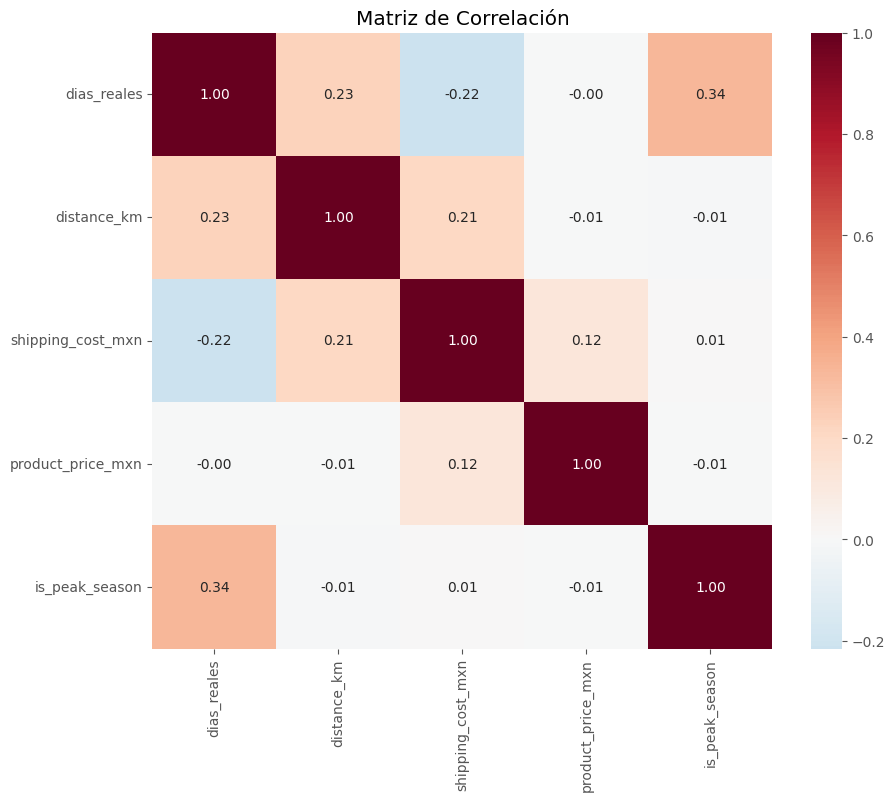

In [6]:
# Mapa de calor para ver la foto completa
graf_corr = au.plot_heatmap_correlaciones(df)
plt.show()

# Conclusiones y Recomendaciones Estratégicas

## Hallazgos Principales
Tras procesar y analizar una muestra de **9,515 envíos validados**, hemos determinado que la eficiencia logística depende de variables estructurales claras:

1.  **Disparidad entre Proveedores:** Existe una brecha significativa en el rendimiento. Mientras carriers privados (como **DHL**) muestran alta consistencia (baja varianza), opciones económicas (como **Correos de México**) introducen incertidumbre en la cadena de suministro, afectando el SLA (Acuerdo de Nivel de Servicio).

2.  **El "Impuesto" de la Temporada Alta:** Se confirmó estadísticamente (**p-value < 0.05**) que la saturación operativa en fechas clave (Hot Sale, Navidad) degrada el servicio, incrementando los tiempos de tránsito promedios de forma considerable.

3.  **Efectividad del Servicio Express:** La correlación negativa entre `costo_envio` y `dias_reales` valida la propuesta de valor: pagar por niveles "Tier Express" reduce efectivamente la espera, independientemente de la distancia.

4.  **Factor Geográfico:** Se detectó que la distancia (`distance_km`) tiene una correlación positiva con el tiempo, pero esta se mitiga en zonas urbanas (`is_urban = 1`), sugiriendo que la infraestructura de "última milla" es más crítica que la distancia carretera pura.